In [ ]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.pyplot as plt

from swissclim_evaluations.cli import _load_yaml, prepare_datasets
from swissclim_evaluations.metrics.probabilistic import (
    crps_ensemble,
    probability_integral_transform,
    run_probabilistic,
)

In [9]:
# Locate configuration relative to the notebook location
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "example_config.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

# Load configuration via project helper to keep parity with CLI
cfg = _load_yaml(cfg_path)

# Prepare datasets using the CLI pipeline (handles selection, alignment, ensemble policy)
ds_gt, ds_ml, ds_std, ds_ml_std = prepare_datasets(cfg)

/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/data.py:101: RuntimeWarning: Rechunking ml to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  warnings.warn(


In [10]:
ds_gt

<xarray.Dataset> Size: 8MB
Dimensions:                  (init_time: 2, lead_time: 1, latitude: 720,
                              longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-05T18:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 00:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B 2023-0...
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 8MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [11]:
ds_ml

<xarray.Dataset> Size: 66MB
Dimensions:                  (init_time: 2, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-05T18:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 00:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 66MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [12]:
# Ensure the config has probabilistic enabled
cfg_modules = cfg.get("modules", {})
if not cfg_modules.get("probabilistic", False):
    print("Enabling modules.probabilistic in-memory for this run…")
    cfg_modules["probabilistic"] = True
    cfg["modules"] = cfg_modules

# Set up output directory from config
out_root = Path(
    cfg.get("paths", {}).get("output_root", "output/verification_esfm")
)
out_root.mkdir(parents=True, exist_ok=True)
print(f"Output root: {out_root}")

# Run the probabilistic module directly (avoids running other modules)
plotting_cfg = cfg.get("plotting", {})
run_probabilistic(ds_gt, ds_ml, out_root, plotting_cfg, cfg)

# Preview saved CSVs (classic module only)
classic_dir = out_root / "probabilistic"
crps_csv_classic = classic_dir / "crps_summary.csv"

Output root: output/verification_esfm
[probabilistic] saved output/verification_esfm/probabilistic/10m_u_component_of_wind_pit_hist.npz
[probabilistic] saved output/verification_esfm/probabilistic/10m_u_component_of_wind_pit.nc
[probabilistic] saved output/verification_esfm/probabilistic/10m_u_component_of_wind_crps.nc
CRPS summary (per variable):
                             CRPS
variable                         
10m_u_component_of_wind  1.008601
[probabilistic] saved output/verification_esfm/probabilistic/crps_summary.csv


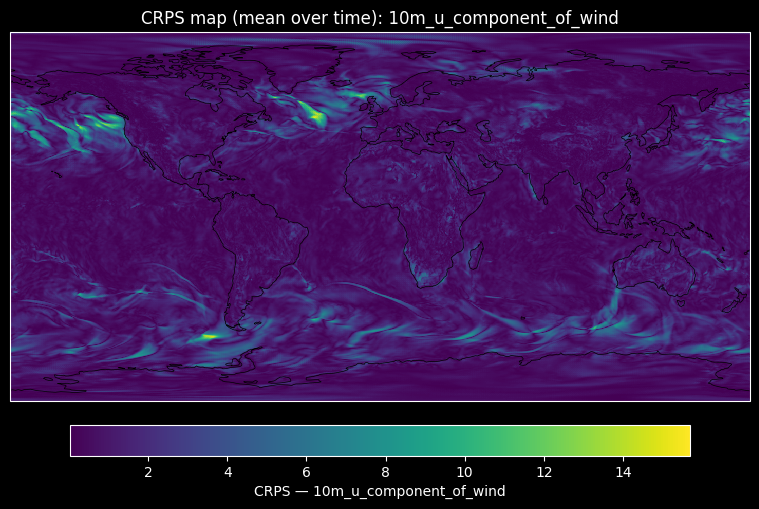

In [15]:
# Pick a map variable: from config if present, otherwise first common variable
vars_cfg = (cfg.get("selection", {}) or {}).get("variables_2d") or list(
    ds_gt.data_vars
)
if not vars_cfg:
    raise ValueError("No variables available to plot.")
map_var = vars_cfg[0]
common = [v for v in ds_gt.data_vars if v in ds_ml.data_vars]
if not common:
    raise ValueError(
        "No overlapping variables between ground truth and model for plotting."
    )
map_var = common[0]

# Compute CRPS field for the chosen variable (pointwise)
crps_da = crps_ensemble(ds_gt[map_var], ds_ml[map_var], ensemble_dim="ensemble")

# Mean over time-like dims to get a map
reduce_dims = [
    d
    for d in ["time", "init_time", "lead_time", "ensemble"]
    if d in crps_da.dims
]
crps_map = crps_da.mean(dim=reduce_dims, skipna=True)

# Detect lat/lon names and sort latitude ascending for pcolormesh
lat_names = [n for n in ["latitude", "lat", "y"] if n in crps_map.coords]
lon_names = [n for n in ["longitude", "lon", "x"] if n in crps_map.coords]
if not lat_names or not lon_names:
    raise ValueError(
        "Could not find latitude/longitude coordinates for plotting."
    )
lat_name, lon_name = lat_names[0], lon_names[0]
if np.any(np.diff(crps_map[lat_name]) < 0):
    crps_map = crps_map.sortby(lat_name)

# Plot with Cartopy as quadmesh
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": proj})
ax.add_feature(cfeature.COASTLINE, lw=0.5)
mesh = ax.pcolormesh(
    crps_map[lon_name],
    crps_map[lat_name],
    crps_map.values,
    cmap="viridis",
    shading="auto",
    transform=ccrs.PlateCarree(),
)
cbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label(f"CRPS — {map_var}")
ax.set_title(f"CRPS map (mean over time): {map_var}")
plt.show()

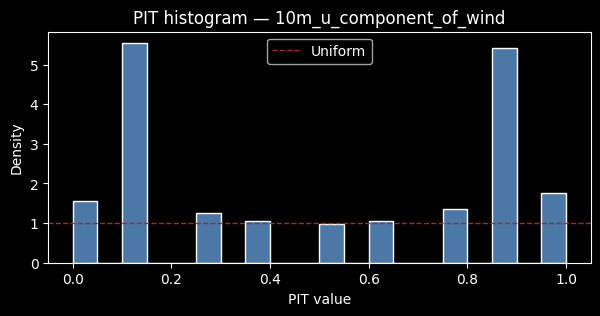

In [17]:
# PIT histogram
# Choose variable and compute PIT for all times/locations, then bin into a histogram
vars_cfg = (cfg.get("selection", {}) or {}).get("variables_2d") or list(
    ds_gt.data_vars
)
if not vars_cfg:
    raise ValueError("No variables available for PIT.")
var = (
    vars_cfg[0]
    if vars_cfg[0] in ds_ml.data_vars
    else [v for v in vars_cfg if v in ds_ml.data_vars][0]
)

pit = probability_integral_transform(
    ds_gt[var], ds_ml[var], ensemble_dim="ensemble", name_prefix=None
)
# Flatten to 1D for a global histogram
pit_flat = pit.values.ravel()
# Remove NaNs
pit_flat = pit_flat[np.isfinite(pit_flat)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(
    pit_flat,
    bins=20,
    range=(0.0, 1.0),
    density=True,
    color="#4C78A8",
    edgecolor="white",
)
ax.set_title(f"PIT histogram — {var}")
ax.set_xlabel("PIT value")
ax.set_ylabel("Density")
# Reference uniform density line
ax.axhline(1.0, color="brown", linestyle="--", linewidth=1, label="Uniform")
ax.legend()
plt.show()